Num GPUs Available:  1
GPU memory growth set.
Found 124486 files belonging to 4 classes.
Using 99589 files for training.
Found 124486 files belonging to 4 classes.
Using 24897 files for validation.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 16)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 32)       0

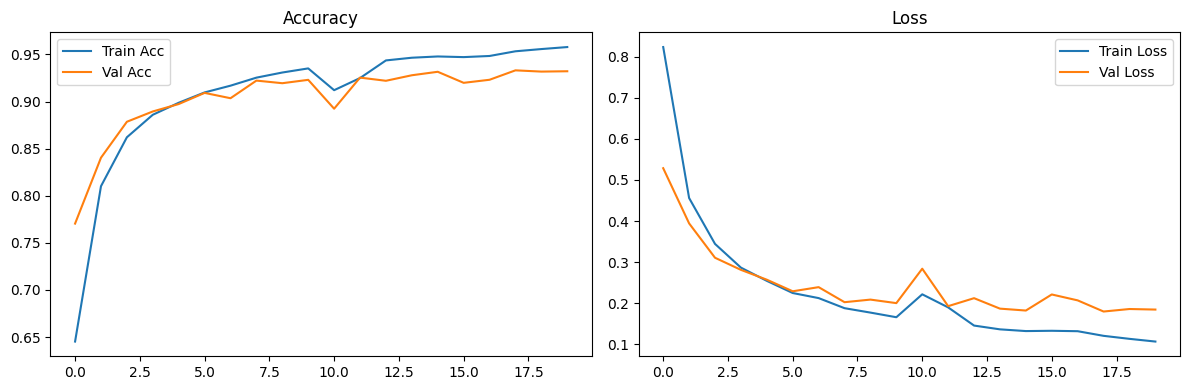

✅ Model saved successfully.


In [ ]:
# -------------------------------
# 1. Imports & GPU Setup
# -------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU memory growth set.")
else:
    print("No GPU found.")

# -------------------------------
# 2. Dataset Preparation
# -------------------------------
data_dir = "dataset"  # your dataset folder
batch_size = 32
img_height = 224
img_width = 224

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Prefetch
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# -------------------------------
# 3. (Optional) Custom LNN Layer
# -------------------------------
class SimpleLNNCell(tf.keras.layers.Layer):
    def __init__(self, units):
        super(SimpleLNNCell, self).__init__()
        self.units = units
        self.state_size = units

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.U = self.add_weight(shape=(self.units, self.units),
                                 initializer='orthogonal',
                                 trainable=True)
        self.b = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True)

    def call(self, inputs, states):
        prev_output = states[0]
        output = tf.nn.tanh(tf.matmul(inputs, self.W) + tf.matmul(prev_output, self.U) + self.b)
        return output, [output]

class LNNLayer(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.rnn = tf.keras.layers.RNN(SimpleLNNCell(units), return_sequences=True)

    def call(self, inputs):
        return self.rnn(inputs)

# -------------------------------
# 4. Build Faster LNN Model
# -------------------------------
def build_lnn_model(input_shape=(224, 224, 3), num_classes=4, use_gru=False):
    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=input_shape),

        layers.Conv2D(16, 3, activation='relu'),
        layers.MaxPooling2D(),  # Downsample

        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),  # Further downsample

        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),  # Additional downsampling added

        # Now shape will be (batch, H, W, C) e.g., (batch, 28, 28, 64)
        layers.Reshape((-1, 64)),  # Convert to (batch, time_steps, features)

        # ✅ Use CuDNN GRU (faster) OR your custom LNN
        layers.Bidirectional(tf.keras.layers.GRU(64, return_sequences=True)) if use_gru else LNNLayer(64),

        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Choose: use_gru=True for speed, use_gru=False for custom LNN
model = build_lnn_model(input_shape=(224, 224, 3), num_classes=num_classes, use_gru=True)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# -------------------------------
# 5. Train
# -------------------------------
epochs = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

# -------------------------------
# 6. Accuracy & Loss Plots
# -------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------------
# 7. Save Model
# -------------------------------
model.save("faster_lnn_model.h5")
print("✅ Model saved successfully.")


1/1 [==============================] - 0s 68ms/step
Confusion Matrix:
[[ 3938   368    45   177]
 [  594  4359    11    84]
 [   42    14  3938   117]
 [  105   112    19 10974]]


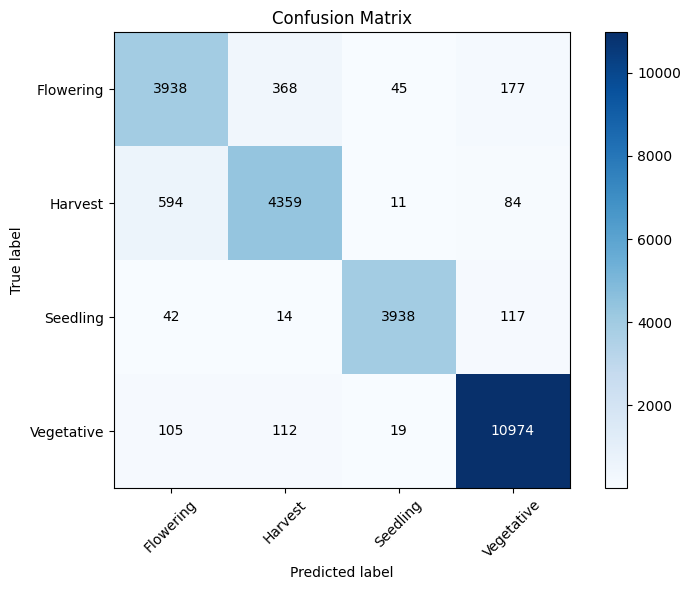

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Get predictions and true labels
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Step 2: Create confusion matrix (manual with NumPy)
num_classes = len(class_names)
confusion_mtx = np.zeros((num_classes, num_classes), dtype=int)

for true, pred in zip(y_true, y_pred):
    confusion_mtx[true][pred] += 1

print("Confusion Matrix:")
print(confusion_mtx)

# Step 3: Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(confusion_mtx, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Annotate cells
thresh = confusion_mtx.max() / 2.
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(confusion_mtx[i, j]),
                 ha="center", va="center",
                 color="white" if confusion_mtx[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 47ms/step


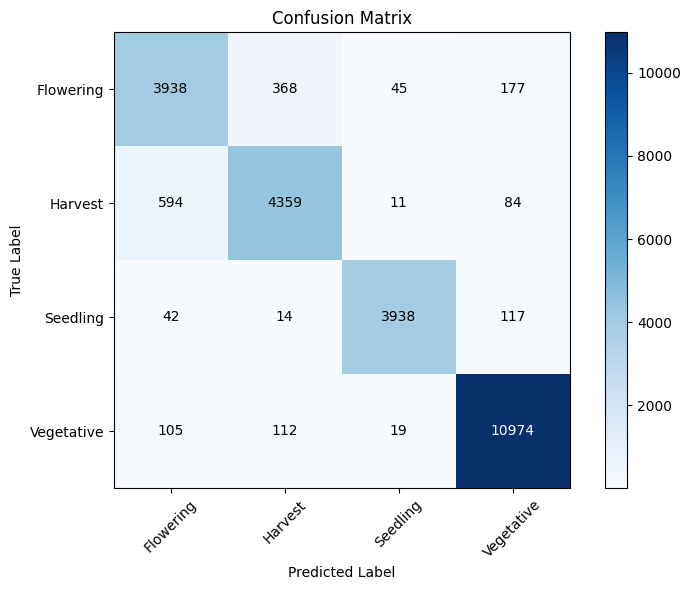

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Collect predictions and true labels
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Step 2: Build confusion matrix using NumPy
num_classes = len(class_names)
confusion_mtx = np.zeros((num_classes, num_classes), dtype=int)

for true, pred in zip(y_true, y_pred):
    confusion_mtx[true][pred] += 1

# Step 3: Plot styled confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(confusion_mtx, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add counts in each cell
thresh = confusion_mtx.max() / 2.
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(confusion_mtx[i, j]),
                 ha="center", va="center",
                 color="white" if confusion_mtx[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


In [ ]:
# -------------------------------
# ✅ Fast Confusion Matrix (Batched)
# -------------------------------

# Step 1: Collect all predictions and labels in batches
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)  # Predict full batch
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Step 2: Build confusion matrix manually
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for t, p in zip(y_true, y_pred):
    conf_matrix[t, p] += 1

# Step 3: Print Confusion Matrix
print("\nConfusion Matrix:")
print("Predicted →", "\t".join(class_names))
for i, row in enumerate(conf_matrix):
    print(f"{class_names[i]:<12}", "\t".join(map(str, row)))

# Step 4: Classification Metrics
print("\nClassification Metrics:")
for i in range(num_classes):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    print(f"{class_names[i]}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")



Confusion Matrix:
Predicted → Flowering	Harvest	Seedling	Vegetative
Flowering    3938	368	45	177
Harvest      594	4359	11	84
Seedling     42	14	3938	117
Vegetative   105	112	19	10974

Classification Metrics:
Flowering:
  Precision: 0.8416
  Recall:    0.8697
  F1-Score:  0.8554
Harvest:
  Precision: 0.8982
  Recall:    0.8635
  F1-Score:  0.8805
Seedling:
  Precision: 0.9813
  Recall:    0.9579
  F1-Score:  0.9695
Vegetative:
  Precision: 0.9667
  Recall:    0.9789
  F1-Score:  0.9728


In [ ]:
from tensorflow.keras.models import load_model

# Load the previously saved model
model = load_model("faster_lnn_model.h5")

# Recompile the model (recommended)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Continue training from epoch 21 to 50
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,             # Total target epoch
    initial_epoch=20       # Resume from this epoch (i.e., start at 21)
)


NameError: name 'train_ds' is not defined

In [ ]:
import tensorflow as tf

# Path and constants (update if needed)
data_dir = "dataset"
batch_size = 32
img_height = 224
img_width = 224

# Load dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Get class names
class_names = train_ds.class_names

# Prefetch for performance
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


Found 124486 files belonging to 4 classes.
Using 99589 files for training.
Found 124486 files belonging to 4 classes.
Using 24897 files for validation.


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("faster_lnn_model.h5")

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    initial_epoch=20
)


Epoch 21/50
3113/3113 [==============================] - 391s 118ms/step - loss: 0.1039 - accuracy: 0.9598 - val_loss: 0.1837 - val_accuracy: 0.9322
Epoch 22/50
3113/3113 [==============================] - 316s 102ms/step - loss: 0.1006 - accuracy: 0.9611 - val_loss: 0.1661 - val_accuracy: 0.9412
Epoch 23/50
3113/3113 [==============================] - 314s 101ms/step - loss: 0.0956 - accuracy: 0.9636 - val_loss: 0.1554 - val_accuracy: 0.9437
Epoch 24/50
3113/3113 [==============================] - 331s 106ms/step - loss: 0.0956 - accuracy: 0.9633 - val_loss: 0.1670 - val_accuracy: 0.9418
Epoch 25/50
3113/3113 [==============================] - 312s 100ms/step - loss: 0.0894 - accuracy: 0.9656 - val_loss: 0.1772 - val_accuracy: 0.9383
Epoch 26/50
3113/3113 [==============================] - 313s 100ms/step - loss: 0.0950 - accuracy: 0.9631 - val_loss: 0.2403 - val_accuracy: 0.9222
Epoch 27/50
3113/3113 [==============================] - 317s 102ms/step - loss: 0.0898 - accuracy: 0.9648

In [ ]:
import tensorflow as tf

# Constants
data_dir = "dataset"
batch_size = 32
img_height = 224
img_width = 224

# -------------------------------
# ✅ Define Data Augmentation Layer
# -------------------------------
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# -------------------------------
# ✅ Load original datasets
# -------------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# -------------------------------
# ✅ Apply augmentation only on training data
# -------------------------------
augmented_train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

# Prefetch for performance
augmented_train_ds = augmented_train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


Found 124486 files belonging to 4 classes.
Using 99589 files for training.
Found 124486 files belonging to 4 classes.
Using 24897 files for validation.


In [ ]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# -------------------------------
# ✅ Load the saved model
# -------------------------------
model = load_model("faster_lnn_model.h5")

# Recompile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# -------------------------------
# ✅ Continue training from epoch 51 to 70
# -------------------------------
history3 = model.fit(
    augmented_train_ds,
    validation_data=val_ds,
    epochs=70,
    initial_epoch=50
)

# Save the new model
model.save("faster_lnn_model_augmented.h5")
print("✅ Model with data augmentation saved.")

Epoch 51/70
3113/3113 [==============================] - 510s 121ms/step - loss: 0.6218 - accuracy: 0.7369 - val_loss: 0.8667 - val_accuracy: 0.6639
Epoch 52/70
3113/3113 [==============================] - 313s 100ms/step - loss: 0.4799 - accuracy: 0.7962 - val_loss: 0.6655 - val_accuracy: 0.7288
Epoch 53/70
3113/3113 [==============================] - 312s 100ms/step - loss: 0.4300 - accuracy: 0.8181 - val_loss: 0.7130 - val_accuracy: 0.7331
Epoch 54/70
3113/3113 [==============================] - 316s 101ms/step - loss: 0.3979 - accuracy: 0.8315 - val_loss: 0.7580 - val_accuracy: 0.7229
Epoch 55/70
3113/3113 [==============================] - 314s 101ms/step - loss: 0.3728 - accuracy: 0.8416 - val_loss: 0.8246 - val_accuracy: 0.7308
Epoch 56/70
3113/3113 [==============================] - 317s 102ms/step - loss: 0.3558 - accuracy: 0.8487 - val_loss: 0.9909 - val_accuracy: 0.6830
Epoch 57/70
3113/3113 [==============================] - 316s 102ms/step - loss: 0.3426 - accuracy: 0.8555